**Import Required Libraries**

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings("ignore")

**Load the Dataset**

In [8]:
df = pd.read_csv("AAPL.csv")

In [9]:
df.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume
0,03-01-2012,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
1,04-01-2012,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2,05-01-2012,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
3,06-01-2012,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
4,09-01-2012,60.785713,61.107143,60.192856,60.247143,52.061932,98506100
5,10-01-2012,60.844284,60.857143,60.214287,60.462856,52.248333,64549100
6,11-01-2012,60.382858,60.407143,59.901428,60.364285,52.163139,53771200
7,12-01-2012,60.325714,60.414288,59.821430,60.198570,52.019955,53146800
8,13-01-2012,59.957142,60.064285,59.808571,59.972858,51.824898,56505400
9,17-01-2012,60.599998,60.855713,60.422855,60.671429,52.428562,60724300


In [10]:
# Convert Date column
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [11]:
# Sort and set index
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

**Basic Data Inspection**

In [12]:
df.shape

(2011, 6)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2011 entries, 2012-01-03 to 2019-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2011 non-null   float64
 1   High       2011 non-null   float64
 2   Low        2011 non-null   float64
 3   Close      2011 non-null   float64
 4   Adj Close  2011 non-null   float64
 5   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 110.0 KB


In [14]:
#Basic statistical summary
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2.011000e+03
mean,126.707469,127.827594,125.580258,126.741235,119.505548,5.949670e+07
std,50.483753,50.926301,50.124940,50.578369,52.438444,4.683856e+07
min,55.424286,57.085712,55.014286,55.790001,48.921928,1.136200e+07
25%,85.882858,86.717858,85.056427,86.202145,75.056679,2.758565e+07
50%,113.050003,114.190002,111.870003,113.050003,105.222908,4.346900e+07
75%,165.190002,167.409996,163.424995,165.245002,160.047111,7.471030e+07
max,291.119995,293.970001,288.119995,291.519989,289.522614,3.765300e+08


**Exploratory Data Analysis**

In [15]:
#Feature Engineering
df["MA07"] = df["Close"].rolling(7).mean()
df["MA30"] = df["Close"].rolling(30).mean()
df["Volatility"] = df["Close"].rolling(10).std()
df["Daily_Returns"] = df["Close"].pct_change()

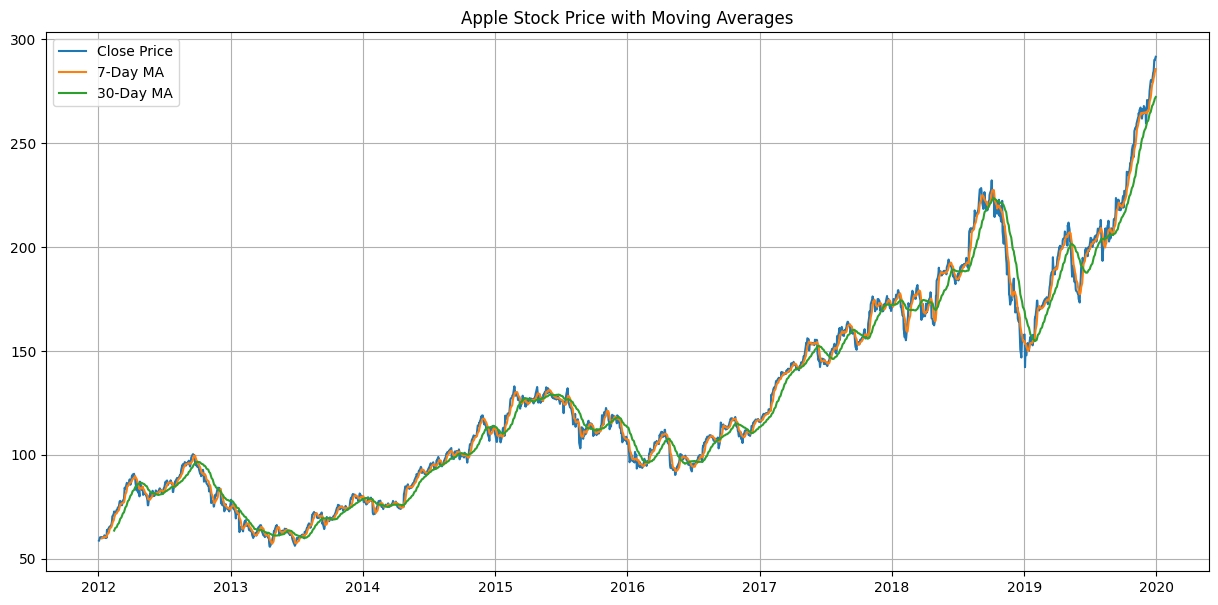

In [16]:
#Price with Moving Averages
plt.figure(figsize=(15,7))
plt.plot(df["Close"], label="Close Price")
plt.plot(df["MA07"], label="7-Day MA")
plt.plot(df["MA30"], label="30-Day MA")
plt.title("Apple Stock Price with Moving Averages")
plt.legend()
plt.grid()
plt.show()

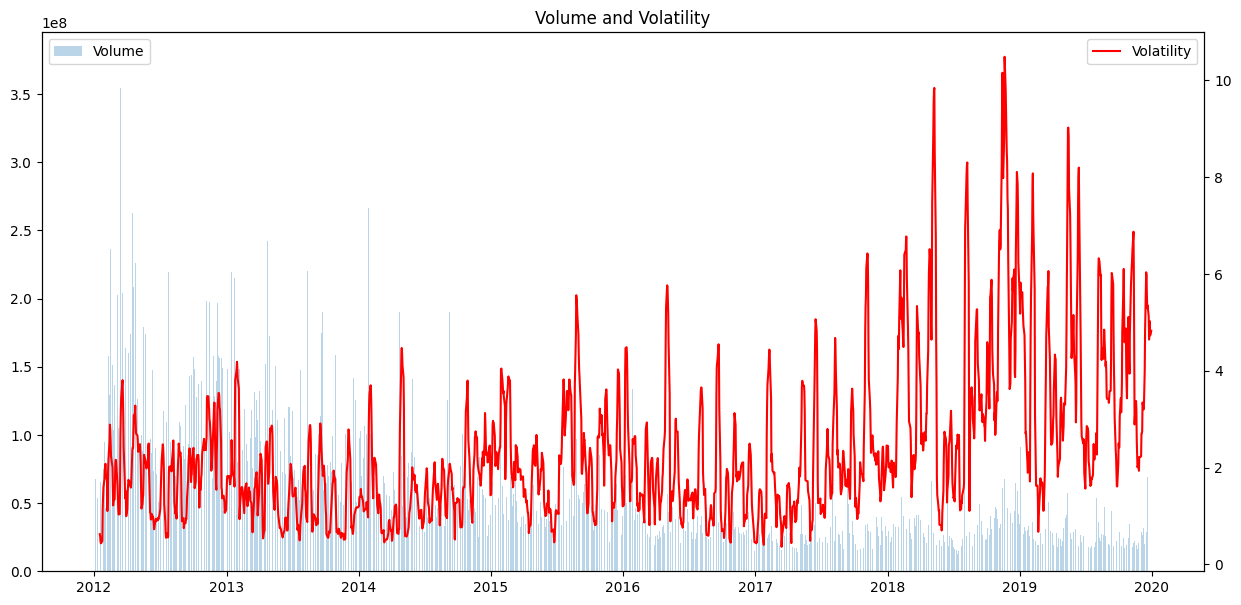

In [17]:
#Volume & Volatility
plt.figure(figsize=(15,7))
plt.bar(df.index, df["Volume"], alpha=0.3, label="Volume")
plt.legend(loc="upper left")

ax2 = plt.gca().twinx()
ax2.plot(df.index, df["Volatility"], color="red", label="Volatility")
ax2.legend(loc="upper right")

plt.title("Volume and Volatility")
plt.show()

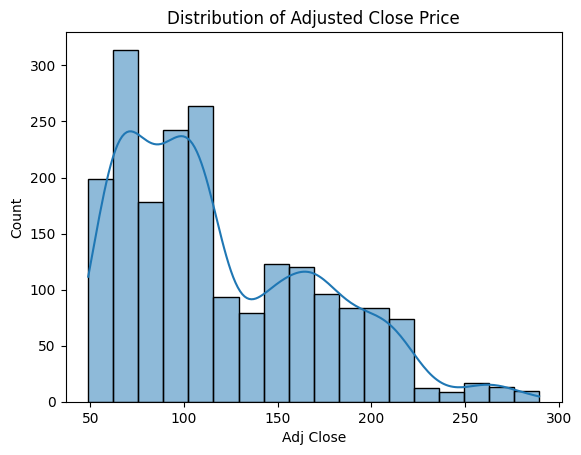

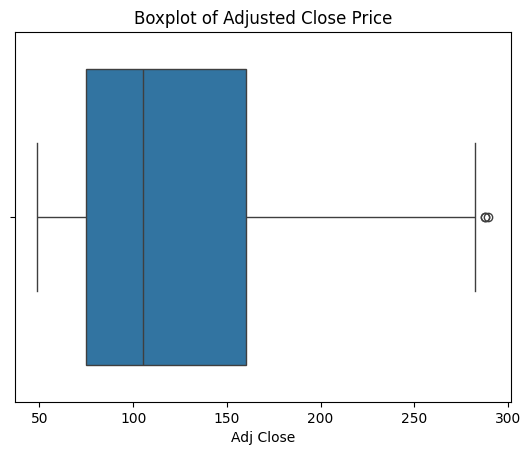

In [18]:
#Distribution Analysis
sns.histplot(df["Adj Close"], kde=True)
plt.title("Distribution of Adjusted Close Price")
plt.show()

sns.boxplot(x=df["Adj Close"])
plt.title("Boxplot of Adjusted Close Price")
plt.show()

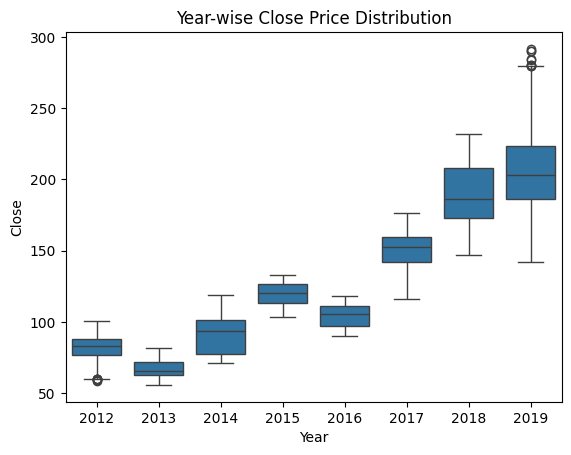

In [19]:
#Year-wise Distribution
df["Year"] = df.index.year
sns.boxplot(x="Year", y="Close", data=df)
plt.title("Year-wise Close Price Distribution")
plt.show()

In [20]:
#Seasonal Decomposition
decomposition = seasonal_decompose(
    df["Close"],
    model="multiplicative",
    period=252
)

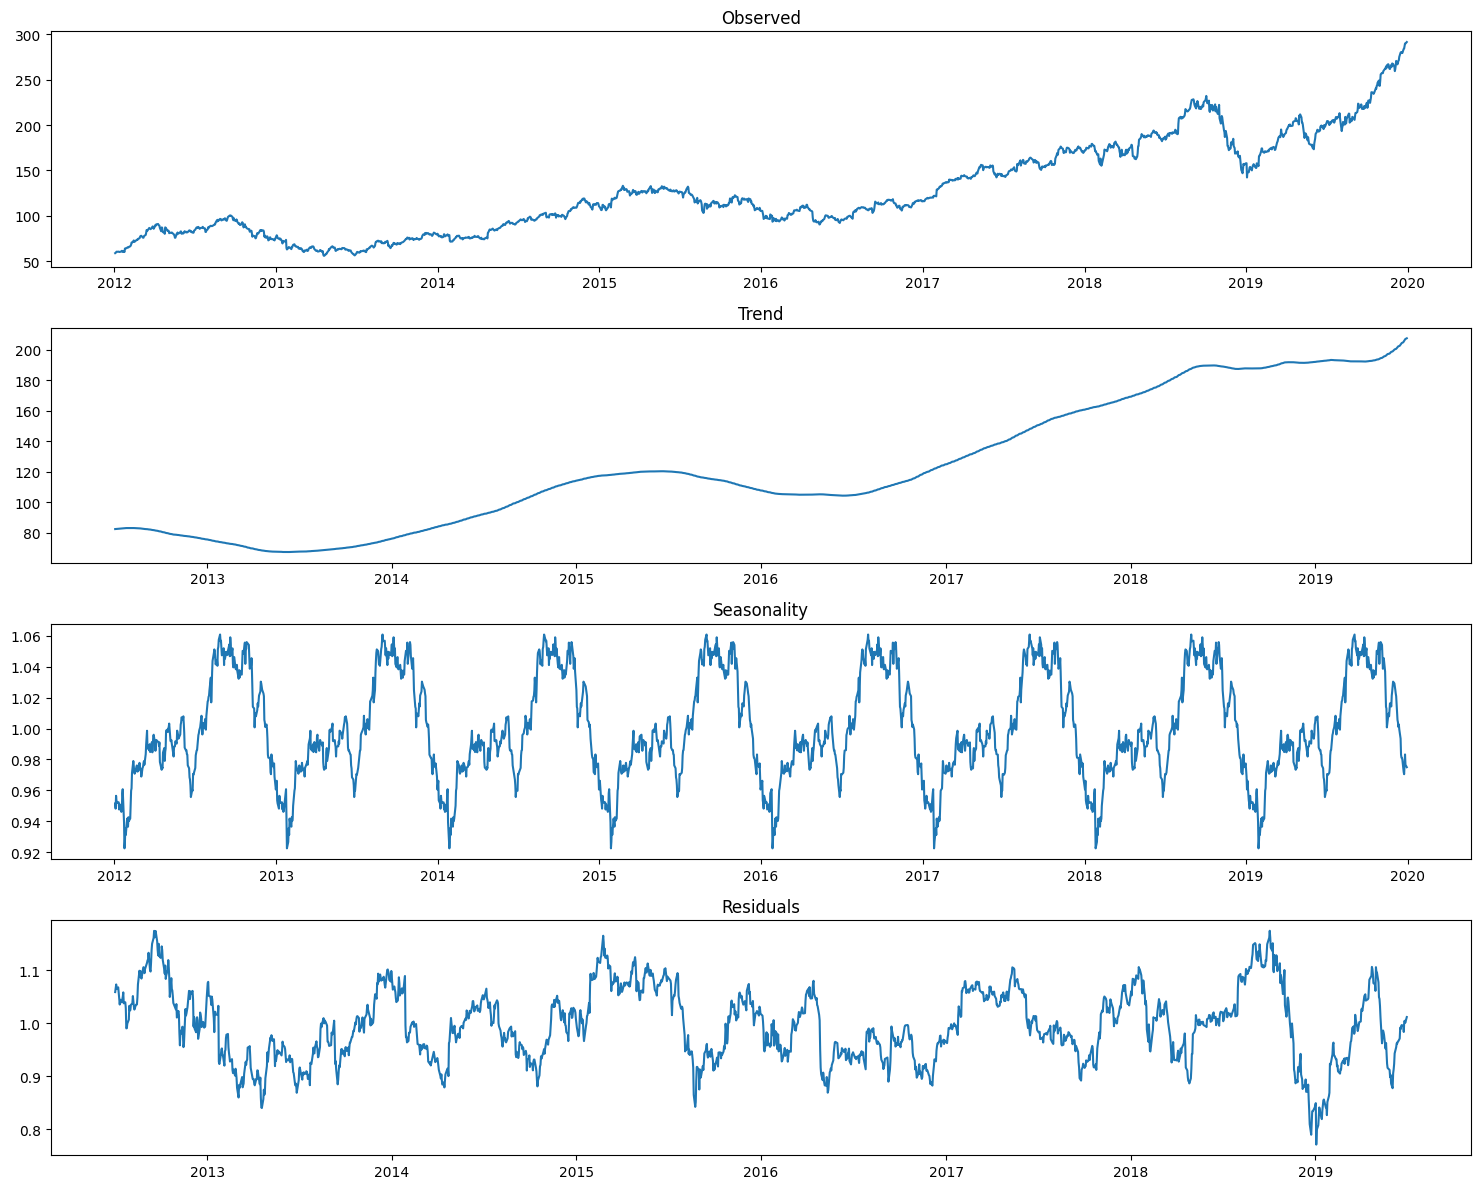

In [21]:
plt.figure(figsize=(15,12))
plt.subplot(4,1,1); plt.plot(decomposition.observed); plt.title("Observed")
plt.subplot(4,1,2); plt.plot(decomposition.trend); plt.title("Trend")
plt.subplot(4,1,3); plt.plot(decomposition.seasonal); plt.title("Seasonality")
plt.subplot(4,1,4); plt.plot(decomposition.resid); plt.title("Residuals")
plt.tight_layout()
plt.show()

In [22]:
#Stationarity Test (ADF)
adf_result = adfuller(df["Close"])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
if adf_result[1] <= 0.05:
  print('result is stationary')
else:
  print('result is non-stationary')

ADF Statistic: 1.2193701254378002
p-value: 0.9961170178032009
result is non-stationary


In [23]:
#Differencing
df["Close_Diff"] = df["Close"].diff()
df.dropna(inplace=True)

adf_diff = adfuller(df["Close_Diff"])
print("\nADF After Differencing:")
print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])


ADF After Differencing:
ADF Statistic: -13.55294624046679
p-value: 2.3898925984374783e-25


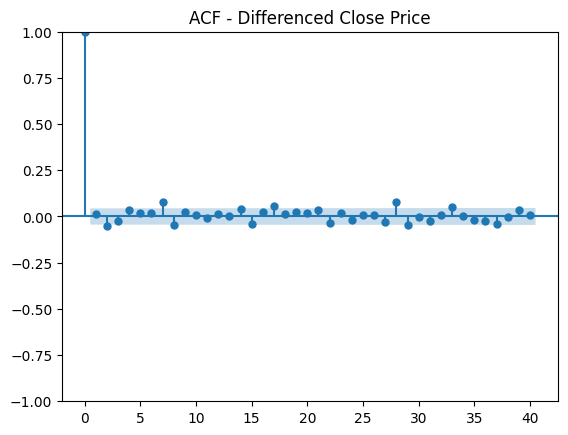

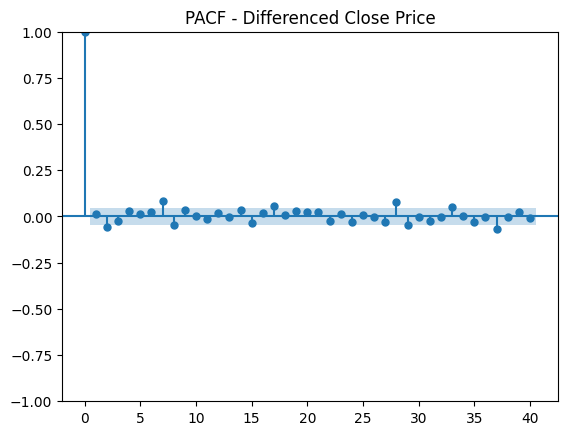

In [24]:
#ACF & PACF
plot_acf(df["Close_Diff"], lags=40)
plt.title("ACF - Differenced Close Price")
plt.show()

plot_pacf(df["Close_Diff"], lags=40)
plt.title("PACF - Differenced Close Price")
plt.show()

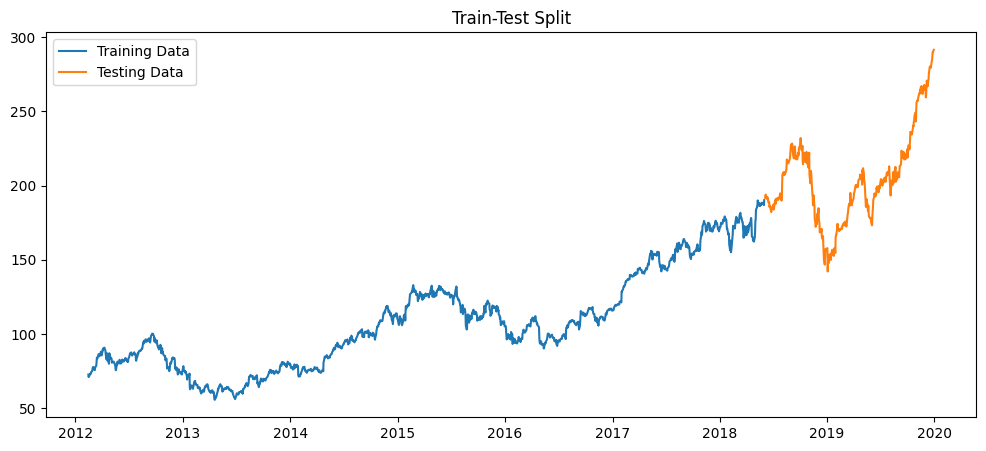

In [25]:
#Train-Test Split
train_size = int(len(df) * 0.8)
train_data = df["Close"].iloc[:train_size]
test_data = df["Close"].iloc[train_size:]

plt.figure(figsize=(12,5))
plt.plot(train_data, label="Training Data")
plt.plot(test_data, label="Testing Data")
plt.legend()
plt.title("Train-Test Split")
plt.show()

#### ARIMA Model


In [26]:
# ARIMA Grid Search
import itertools

p = range(0,6)
d = [1]
q = range(0,6)

best_aic = float("inf")
best_order = None

for order in itertools.product(p, d, q):
    try:
        model = ARIMA(train_data, order=order)
        model_fit = model.fit()
        if model_fit.aic < best_aic:
            best_aic = model_fit.aic
            best_order = order
    except:
        continue

print("Best ARIMA Order:", best_order)

Best ARIMA Order: (2, 1, 2)


RMSE: 33.38683134932621
MAPE: 0.11538266319651028


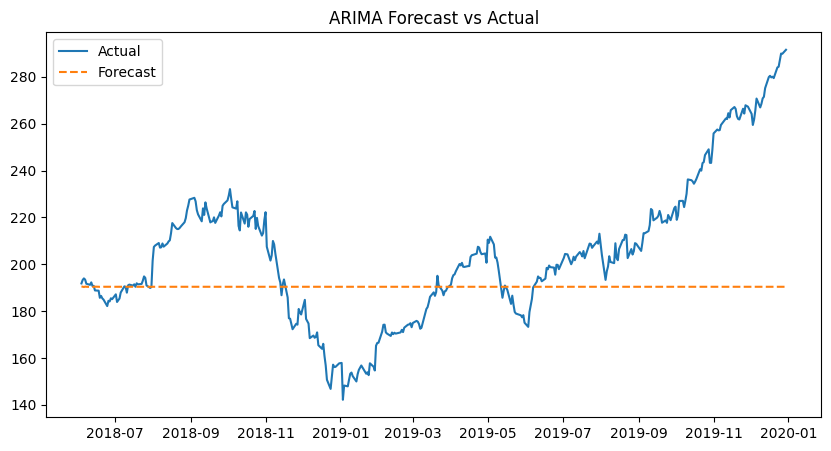

In [27]:
#ARIMA Model
final_model = ARIMA(train_data, order=best_order)
final_fit = final_model.fit()

forecast = final_fit.forecast(steps=len(test_data))

rmse = np.sqrt(mean_squared_error(test_data, forecast))
mape = mean_absolute_percentage_error(test_data, forecast)

print("RMSE:", rmse)
print("MAPE:", mape)

plt.figure(figsize=(10,5))
plt.plot(test_data.index, test_data, label="Actual")
plt.plot(test_data.index, forecast, label="Forecast", linestyle="--")
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

**30-DAY FUTURE FORECAST**

In [28]:
# Refit ARIMA on FULL dataset
final_model_full = ARIMA(df["Close"], order=best_order)
final_fit_full = final_model_full.fit()

In [29]:
# Forecast next 30 trading days
future_30 = final_fit_full.forecast(steps=30)

In [30]:
# Create future business-day dates
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq="B"
)

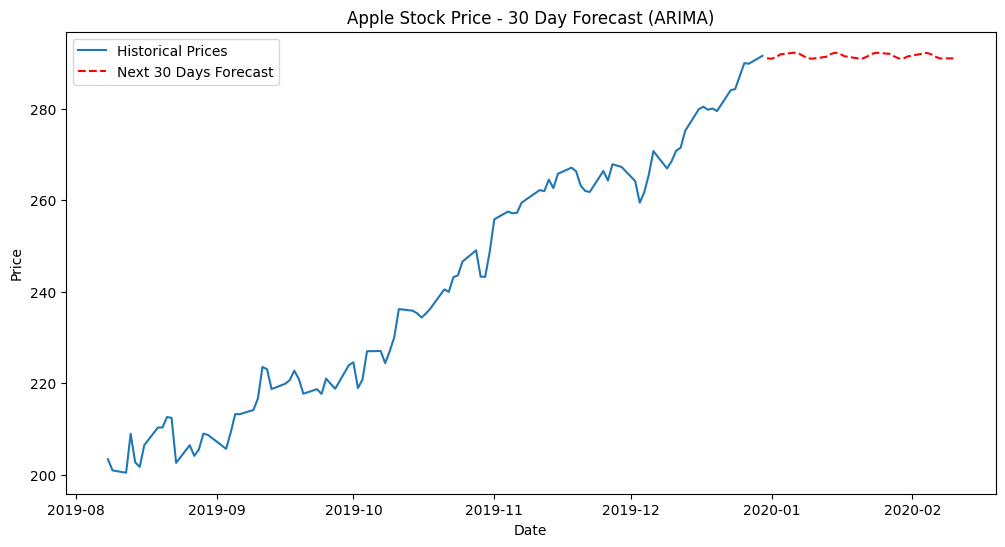

In [31]:
# Plot future forecast
plt.figure(figsize=(12,6))
plt.plot(df["Close"].tail(100), label="Historical Prices")
plt.plot(future_dates, future_30, label="Next 30 Days Forecast", linestyle="--", color="red")
plt.title("Apple Stock Price - 30 Day Forecast (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

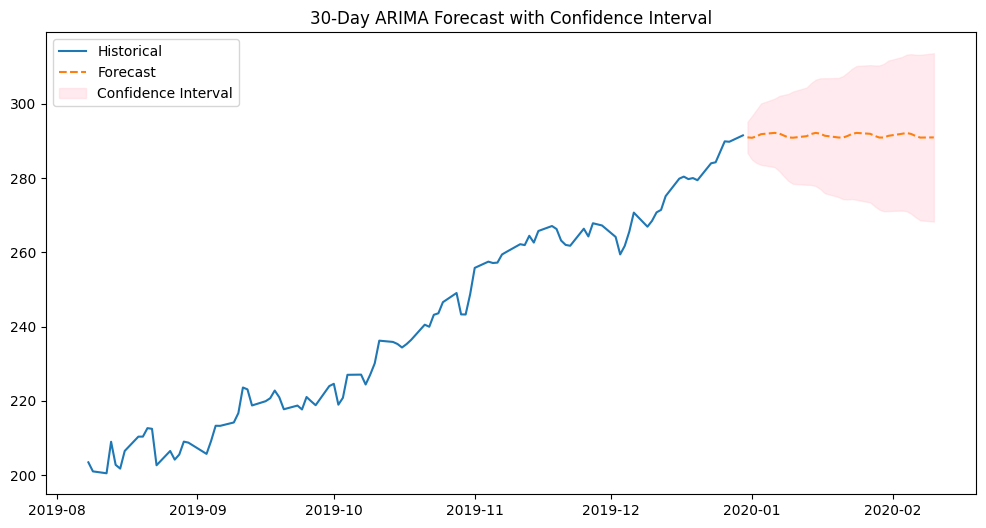

In [32]:
forecast_res = final_fit_full.get_forecast(steps=30)
conf_int = forecast_res.conf_int()

plt.figure(figsize=(12,6))
plt.plot(df["Close"].tail(100), label="Historical")
plt.plot(future_dates, forecast_res.predicted_mean, label="Forecast", linestyle="--")
plt.fill_between(
    future_dates,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="Confidence Interval"
)
plt.legend()
plt.title("30-Day ARIMA Forecast with Confidence Interval")
plt.show()


#### SARIMA

In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

In [34]:
# SARIMA CONFIGURATION (SARIMA-B)

order = (2, 1, 2)
seasonal_order = (0, 1, 1, 5)
"""
Weekly seasonality:
5  -> Trading days in a week
D=1 -> Removes weekly seasonal trend
MA=1-> Captures short-term weekly shocks

Chosen for:
- Faster training
- Weak seasonality in stock prices
- Better interpretability
"""


'\nWeekly seasonality:\n5  -> Trading days in a week\nD=1 -> Removes weekly seasonal trend\nMA=1-> Captures short-term weekly shocks\n\nChosen for:\n- Faster training\n- Weak seasonality in stock prices\n- Better interpretability\n'

In [35]:
print(f"Training SARIMA{order} x {seasonal_order} on training data...")

sarima_model = SARIMAX(
    train_data,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
print("SARIMA model trained successfully.")
print(sarima_fit.summary())

Training SARIMA(2, 1, 2) x (0, 1, 1, 5) on training data...
SARIMA model trained successfully.
                                      SARIMAX Results                                      
Dep. Variable:                               Close   No. Observations:                 1585
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 5)   Log Likelihood               -3037.910
Date:                             Sun, 21 Dec 2025   AIC                           6087.820
Time:                                     22:09:16   BIC                           6119.977
Sample:                                          0   HQIC                          6099.772
                                            - 1585                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1      

In [36]:
# Forecast on test data
sarima_forecast = sarima_fit.forecast(steps=len(test_data))

# Evaluation metrics
sarima_rmse = np.sqrt(mean_squared_error(test_data, sarima_forecast))
sarima_mape = mean_absolute_percentage_error(test_data, sarima_forecast)

print(f"SARIMA RMSE: {sarima_rmse:.2f}")
print(f"SARIMA MAPE: {sarima_mape:.4f}")

SARIMA RMSE: 26.73
SARIMA MAPE: 0.1053


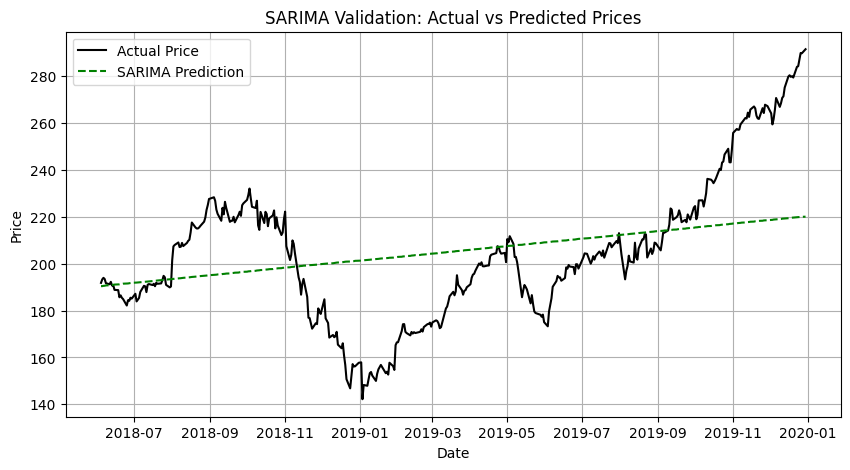

In [37]:
# Plot validation results
plt.figure(figsize=(10,5))
plt.plot(test_data.index, test_data, label="Actual Price", color="black")
plt.plot(test_data.index, sarima_forecast, label="SARIMA Prediction", linestyle="--", color="green")
plt.title("SARIMA Validation: Actual vs Predicted Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
# Retrain SARIMA on FULL dataset for future forecasting
sarima_full_model = SARIMAX(
    df["Close"],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_full_fit = sarima_full_model.fit(disp=False)
print("SARIMA retrained on full data.")


SARIMA retrained on full data.


In [39]:
# Forecast next 30 trading days
sarima_future = sarima_full_fit.get_forecast(steps=30)
sarima_mean = sarima_future.predicted_mean
sarima_conf = sarima_future.conf_int()

# Create future business-day dates
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq="B"
)

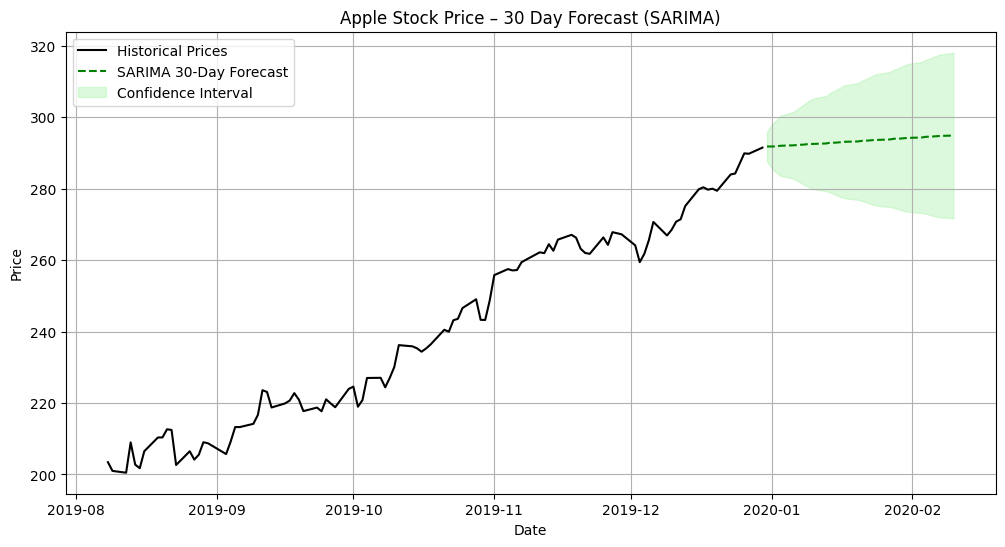

In [40]:
plt.figure(figsize=(12,6))
plt.plot(df["Close"].tail(100), label="Historical Prices", color="black")
plt.plot(future_dates, sarima_mean, label="SARIMA 30-Day Forecast", linestyle="--", color="green")

plt.fill_between(
    future_dates,
    sarima_conf.iloc[:, 0],
    sarima_conf.iloc[:, 1],
    color="lightgreen",
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("Apple Stock Price – 30 Day Forecast (SARIMA)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


### Random Forest Model

In [41]:
# RANDOM FOREST — FEATURE PREPARATION

from sklearn.model_selection import train_test_split

# Features for ML models
rf_features = [
    "Open",
    "High",
    "Low",
    "Volume",
    "MA07",
    "MA30",
    "Volatility",
    "Daily_Returns"
]

# Drop rows with NaNs created by rolling features
rf_df = df[rf_features + ["Close"]].dropna()

X = rf_df[rf_features]
y = rf_df["Close"]

# Time-series split (NO SHUFFLING)
train_size = int(len(rf_df) * 0.8)
X_train_rf = X.iloc[:train_size]
X_test_rf = X.iloc[train_size:]
y_train_rf = y.iloc[:train_size]
y_test_rf = y.iloc[train_size:]

print("RF Train shape:", X_train_rf.shape)
print("RF Test shape :", X_test_rf.shape)


RF Train shape: (1585, 8)
RF Test shape : (397, 8)


Random Forest RMSE: 32.31
Random Forest MAPE: 0.0905


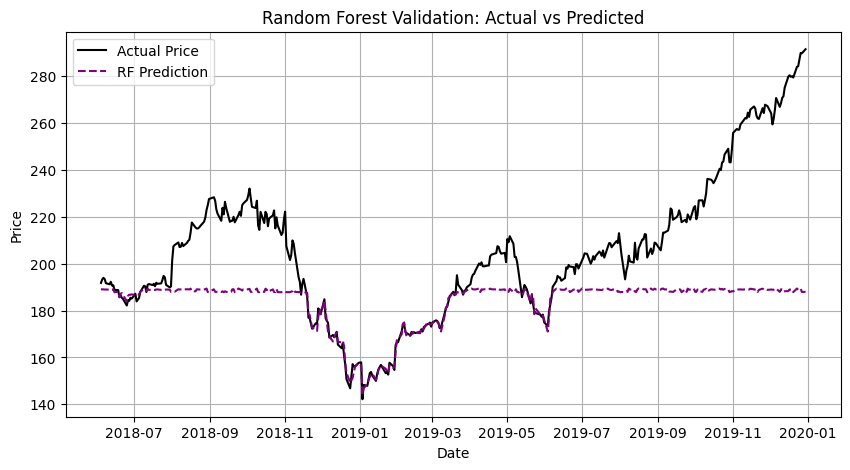

In [42]:
# RANDOM FOREST — TRAINING & EVALUATION

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)

# Predict on test set
rf_pred = rf_model.predict(X_test_rf)

# Evaluation metrics
rf_rmse = np.sqrt(mean_squared_error(y_test_rf, rf_pred))
rf_mape = mean_absolute_percentage_error(y_test_rf, rf_pred)

print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest MAPE: {rf_mape:.4f}")

# Plot validation results
plt.figure(figsize=(10,5))
plt.plot(y_test_rf.index, y_test_rf, label="Actual Price", color="black")
plt.plot(y_test_rf.index, rf_pred, label="RF Prediction", linestyle="--", color="purple")
plt.title("Random Forest Validation: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


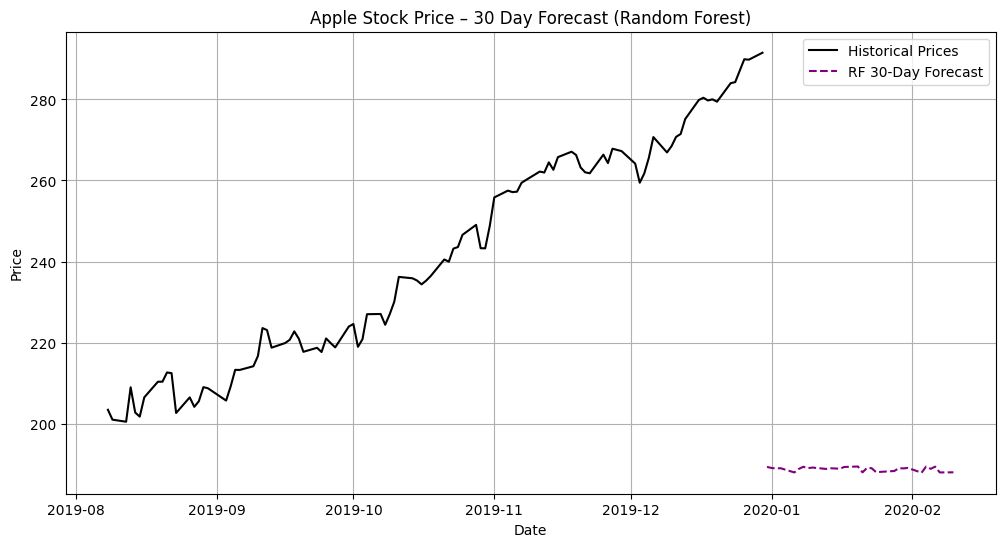

In [43]:
# RANDOM FOREST — 30 DAY FORECAST

# Use last 30 available feature rows as proxy for next 30 days
last_30_features = X.tail(30)

rf_future_30 = rf_model.predict(last_30_features)

# Create future business-day dates
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq="B"
)

# Plot RF future forecast
plt.figure(figsize=(12,6))
plt.plot(df["Close"].tail(100), label="Historical Prices", color="black")
plt.plot(future_dates, rf_future_30, label="RF 30-Day Forecast", linestyle="--", color="purple")
plt.title("Apple Stock Price – 30 Day Forecast (Random Forest)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


### XGBOOST

In [44]:
# XGBOOST — FEATURE PREPARATION

from xgboost import XGBRegressor

# Reuse the same features as Random Forest
xgb_features = [
    "Open",
    "High",
    "Low",
    "Volume",
    "MA07",
    "MA30",
    "Volatility",
    "Daily_Returns"
]

xgb_df = df[xgb_features + ["Close"]].dropna()

X = xgb_df[xgb_features]
y = xgb_df["Close"]

# Time-series split (NO SHUFFLE)
train_size = int(len(xgb_df) * 0.8)

X_train_xgb = X.iloc[:train_size]
X_test_xgb = X.iloc[train_size:]
y_train_xgb = y.iloc[:train_size]
y_test_xgb = y.iloc[train_size:]

print("XGB Train shape:", X_train_xgb.shape)
print("XGB Test shape :", X_test_xgb.shape)


XGB Train shape: (1585, 8)
XGB Test shape : (397, 8)


XGBoost RMSE: 32.49
XGBoost MAPE: 0.0914


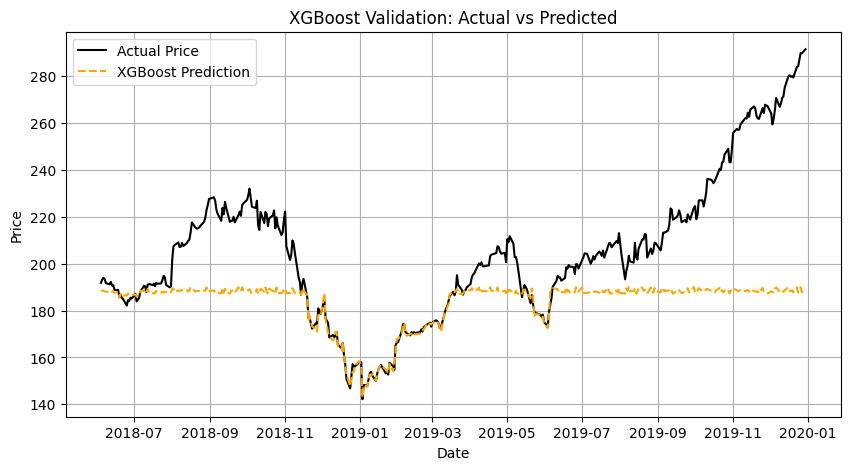

In [45]:
# XGBOOST — TRAINING & EVALUATION

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train_xgb, y_train_xgb)

# Predict on test set
xgb_pred = xgb_model.predict(X_test_xgb)

# Evaluation
xgb_rmse = np.sqrt(mean_squared_error(y_test_xgb, xgb_pred))
xgb_mape = mean_absolute_percentage_error(y_test_xgb, xgb_pred)

print(f"XGBoost RMSE: {xgb_rmse:.2f}")
print(f"XGBoost MAPE: {xgb_mape:.4f}")

# Plot validation results
plt.figure(figsize=(10,5))
plt.plot(y_test_xgb.index, y_test_xgb, label="Actual Price", color="black")
plt.plot(y_test_xgb.index, xgb_pred, label="XGBoost Prediction", linestyle="--", color="orange")
plt.title("XGBoost Validation: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

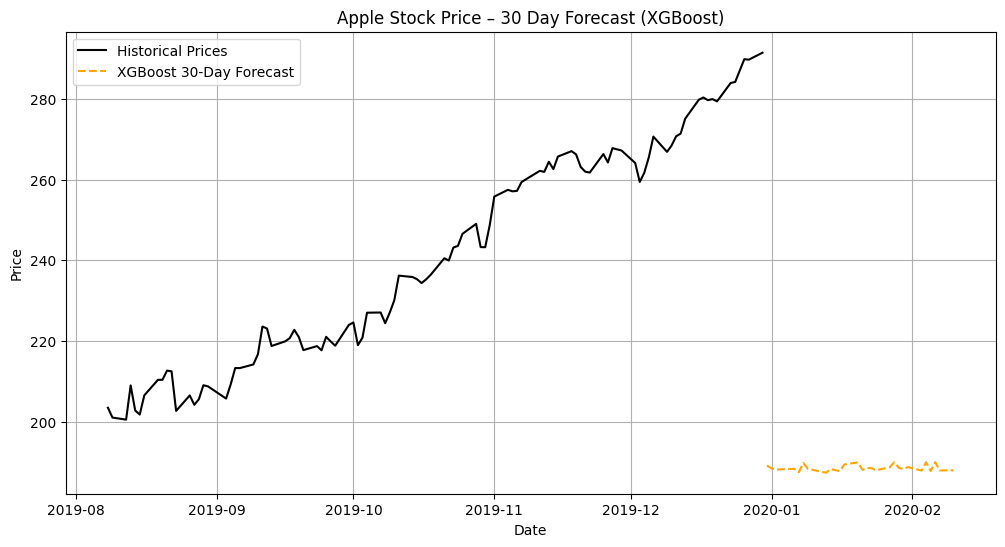

In [46]:
# XGBOOST — 30 DAY FORECAST

# Use last 30 feature rows as proxy for future inputs
last_30_xgb_features = X.tail(30)

xgb_future_30 = xgb_model.predict(last_30_xgb_features)

# Create future business-day dates
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq="B"
)

# Plot future forecast
plt.figure(figsize=(12,6))
plt.plot(df["Close"].tail(100), label="Historical Prices", color="black")
plt.plot(future_dates, xgb_future_30, label="XGBoost 30-Day Forecast", linestyle="--", color="orange")
plt.title("Apple Stock Price – 30 Day Forecast (XGBoost)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


### LSTM

In [47]:
# LSTM — DATA PREPARATION

from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Use only Close price for LSTM
close_data = df[['Close']].values

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close = scaler.fit_transform(close_data)

# Function to create sequences
def create_sequences(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

LOOKBACK = 60

X_lstm, y_lstm = create_sequences(scaled_close, LOOKBACK)

# Train-test split (time-based)
train_size = int(len(X_lstm) * 0.8)

X_train_lstm = X_lstm[:train_size]
X_test_lstm = X_lstm[train_size:]
y_train_lstm = y_lstm[:train_size]
y_test_lstm = y_lstm[train_size:]

# Reshape for LSTM [samples, timesteps, features]
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

print("LSTM Train shape:", X_train_lstm.shape)
print("LSTM Test shape :", X_test_lstm.shape)

LSTM Train shape: (1537, 60, 1)
LSTM Test shape : (385, 60, 1)


In [48]:
# LSTM — MODEL BUILDING & TRAINING

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0174 - val_loss: 0.0021
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 7.6792e-04 - val_loss: 6.7623e-04
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 6.6969e-04 - val_loss: 8.6480e-04
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.0697e-04 - val_loss: 8.5806e-04
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 6.4605e-04 - val_loss: 6.7092e-04
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 6.2775e-04 - val_loss: 6.4071e-04
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 5.8307e-04 - val_loss: 6.5477e-04
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 5.6478e-04 - val_loss: 7.3205e-04
Epoch 9/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 4.9815e-04 - val_loss: 6.8729e-04
Epoch 10/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 5.1817e-04 - val_loss: 6.2782e-04
Epoch 11/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.5825e-04 - val_

In [49]:
# LSTM — MODEL EVALUATION

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# Predict on test data
lstm_pred_scaled = lstm_model.predict(X_test_lstm)

# Inverse scaling
lstm_pred = scaler.inverse_transform(lstm_pred_scaled.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test_lstm.reshape(-1,1))

# Metrics
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
lstm_mape = mean_absolute_percentage_error(y_test_actual, lstm_pred)

print(f"LSTM RMSE: {lstm_rmse:.2f}")
print(f"LSTM MAPE: {lstm_mape:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
LSTM RMSE: 5.54
LSTM MAPE: 0.0214


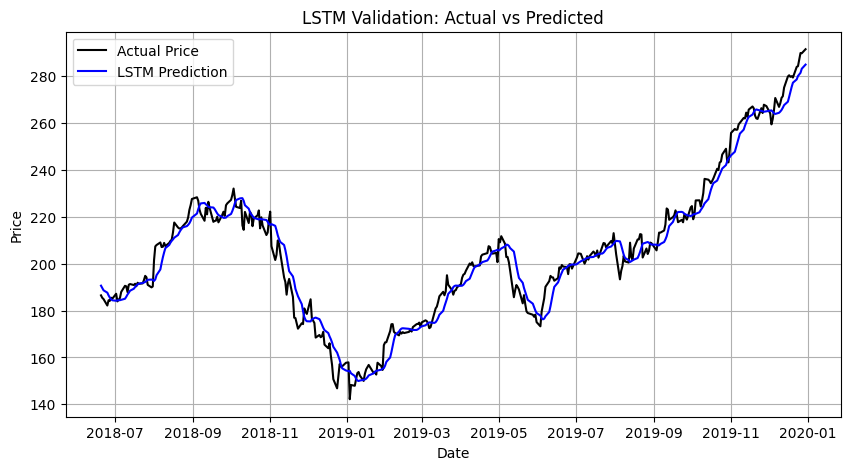

In [50]:
# Plot validation results
plt.figure(figsize=(10,5))
plt.plot(df.index[-len(y_test_actual):], y_test_actual, label="Actual Price", color="black")
plt.plot(df.index[-len(lstm_pred):], lstm_pred, label="LSTM Prediction", color="blue")
plt.title("LSTM Validation: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━

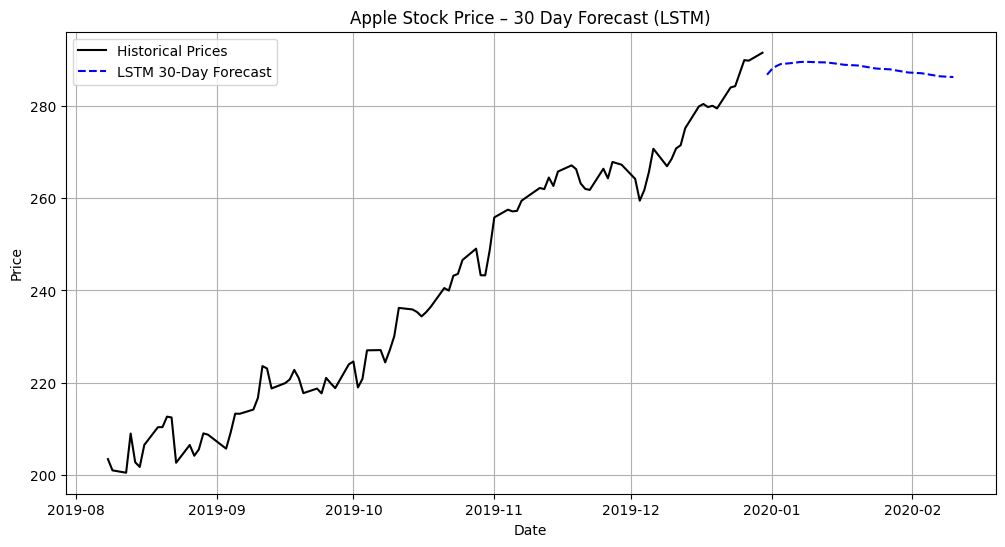

In [51]:
# LSTM — 30 DAY FUTURE FORECAST

# Take last LOOKBACK days
last_sequence = scaled_close[-LOOKBACK:]

future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(30):
    current_sequence_reshaped = current_sequence.reshape((1, LOOKBACK, 1))
    next_pred = lstm_model.predict(current_sequence_reshaped)
    future_predictions.append(next_pred[0, 0])
    
    # Slide window
    current_sequence = np.append(current_sequence[1:], next_pred, axis=0)

# Inverse scaling
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

# Future dates
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq="B"
)

# Plot future forecast
plt.figure(figsize=(12,6))
plt.plot(df["Close"].tail(100), label="Historical Prices", color="black")
plt.plot(future_dates, future_predictions, label="LSTM 30-Day Forecast", linestyle="--", color="blue")
plt.title("Apple Stock Price – 30 Day Forecast (LSTM)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()
